In [10]:
import pandas as pd

# Load datasets from the same folder as your notebook
students = pd.read_csv("student_Dataset.csv")
print("Students shape:", students.shape)


Students shape: (181, 20)


In [9]:
# Count duplicates
num_dupes = students.duplicated().sum()
print(f"Number of duplicate rows: {num_dupes}")

# Count missing values per column
missing_counts = students.isnull().sum()

# Show only columns with missing values
missing_summary = missing_counts[missing_counts > 0]
print("\nColumns with missing values and their counts:")
print(missing_summary)

Number of duplicate rows: 1

Columns with missing values and their counts:
Department       1
Year_of_Study    2
Section          1
dtype: int64


In [22]:
# Remove duplicates
students_clean = students.drop_duplicates()

# Fill missing values: "NULL" for text, 0 for numbers
students_clean = students_clean.fillna({
    'Department': "NULL",
    'Year_of_Study': 0,
    'Section': "NULL",
    'Email_ID': "NULL",
    'Mobile_Number': "NULL",
    'Age': 0,
    'CGPA': 0,
    'Attendance_Percentage': 0
})

print("Students cleaned shape:", students_clean.shape)
print("Missing values after cleaning:\n", students_clean.isnull().sum())
students_clean.to_csv("students_clean.csv", index=False)

Students cleaned shape: (180, 20)
Missing values after cleaning:
 Student_ID               0
Student_Name             0
Gender                   0
Age                      0
Department               0
Year_of_Study            0
Section                  0
Roll_Number              0
Student_Type             0
Admission_Year           0
Semester                 0
CGPA                     0
Attendance_Percentage    0
Academic_Performance     0
Scholarship_Status       0
Hostel_DayScholar        0
Mobile_Number            0
Email_ID                 0
City                     0
State                    0
dtype: int64


=== BEFORE CLEANING ===
Total rows: 181
Duplicate rows: 1
Missing values per column:
Department       1
Year_of_Study    2
Section          1
dtype: int64

=== AFTER CLEANING ===
Total rows: 180
Duplicate rows: 0
Missing values per column:
Series([], dtype: int64)


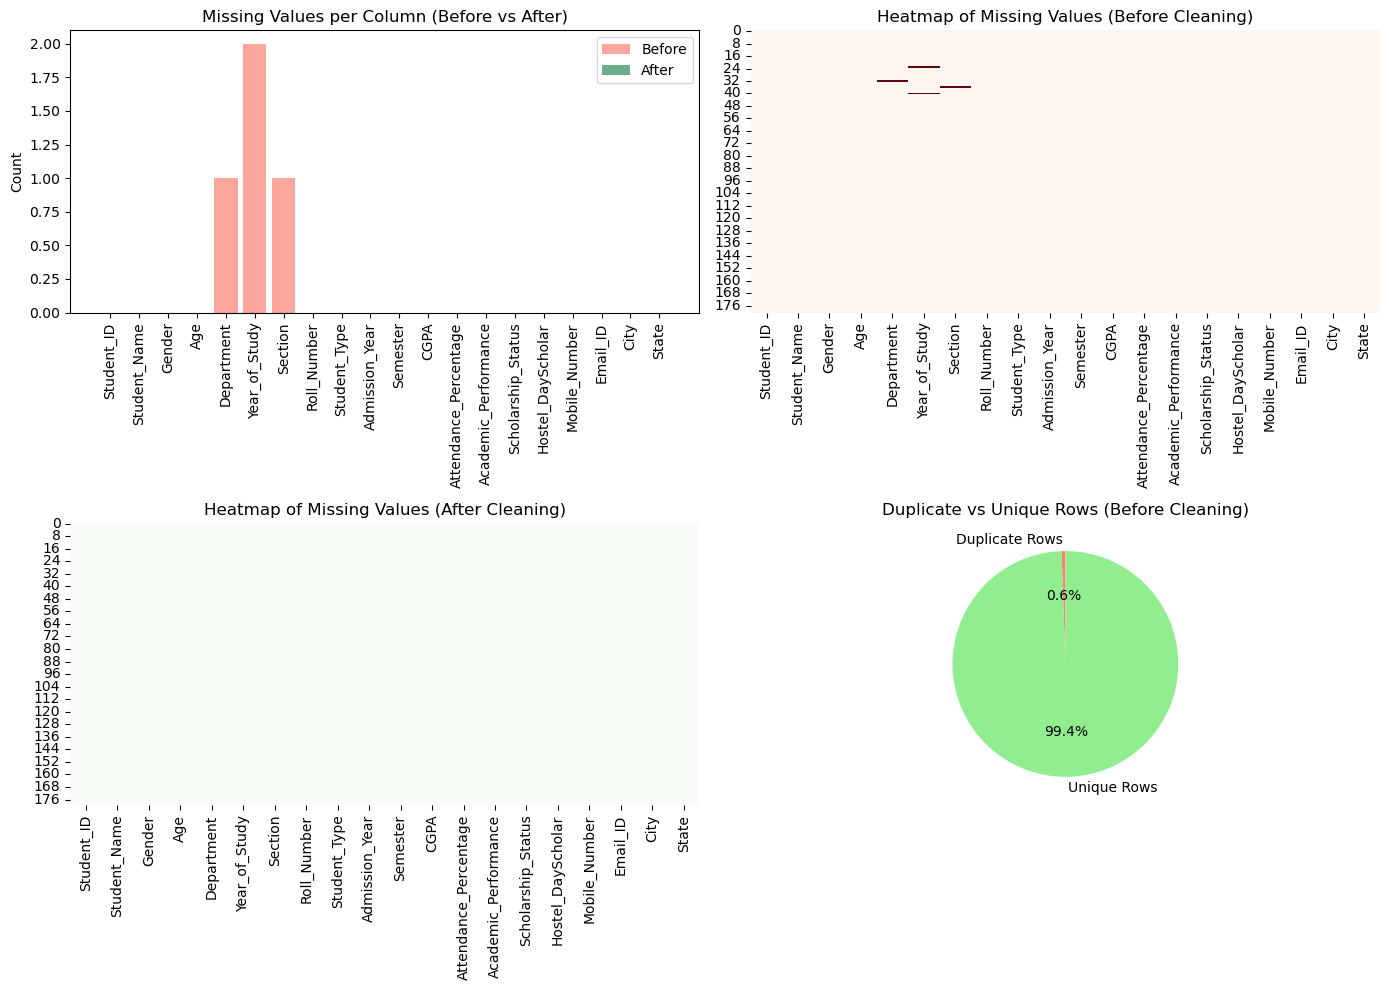

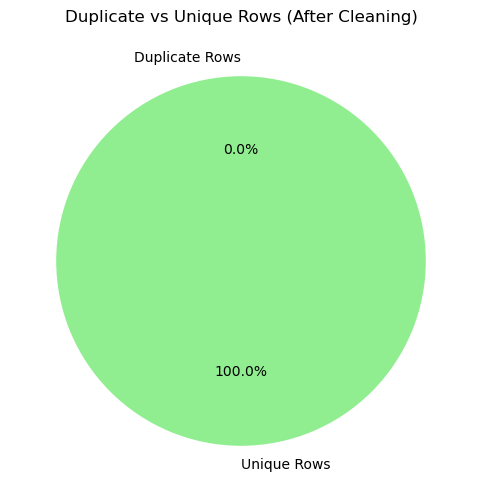

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load dataset ---
students = pd.read_csv(r"student_Dataset.csv")

# --- Clean dataset ---
students_clean = students.drop_duplicates().fillna({
    'Department': "NULL",
    'Year_of_Study': 0,
    'Section': "NULL",
    'Email_ID': "NULL",
    'Mobile_Number': "NULL",
    'Age': 0,
    'CGPA': 0,
    'Attendance_Percentage': 0
})

# -----------------------------
# Textual Summary
# -----------------------------
print("=== BEFORE CLEANING ===")
print(f"Total rows: {students.shape[0]}")
print(f"Duplicate rows: {students.duplicated().sum()}")
print("Missing values per column:")
print(students.isnull().sum()[students.isnull().sum() > 0])

print("\n=== AFTER CLEANING ===")
print(f"Total rows: {students_clean.shape[0]}")
print(f"Duplicate rows: {students_clean.duplicated().sum()}")
print("Missing values per column:")
print(students_clean.isnull().sum()[students_clean.isnull().sum() > 0])

# -----------------------------
# Graphical Representation
# -----------------------------

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1. Missing values per column (Before vs After)
missing_before = students.isnull().sum()
missing_after = students_clean.isnull().sum()

axes[0,0].bar(missing_before.index, missing_before.values, color="salmon", alpha=0.7, label="Before")
axes[0,0].bar(missing_after.index, missing_after.values, color="seagreen", alpha=0.7, label="After")
axes[0,0].set_title("Missing Values per Column (Before vs After)")
axes[0,0].set_ylabel("Count")
axes[0,0].tick_params(axis='x', rotation=90)
axes[0,0].legend()

# 2. Heatmap Before Cleaning
sns.heatmap(students.isnull(), cbar=False, cmap="Reds", ax=axes[0,1])
axes[0,1].set_title("Heatmap of Missing Values (Before Cleaning)")

# 3. Heatmap After Cleaning
sns.heatmap(students_clean.isnull(), cbar=False, cmap="Greens", ax=axes[1,0])
axes[1,0].set_title("Heatmap of Missing Values (After Cleaning)")

# 4. Duplicate vs Unique Rows (Pie chart Before vs After)
labels = ["Duplicate Rows", "Unique Rows"]
sizes_before = [students.duplicated().sum(), len(students) - students.duplicated().sum()]
sizes_after = [students_clean.duplicated().sum(), len(students_clean) - students_clean.duplicated().sum()]

axes[1,1].pie(sizes_before, labels=labels, autopct="%1.1f%%", colors=["salmon","lightgreen"], startangle=90)
axes[1,1].set_title("Duplicate vs Unique Rows (Before Cleaning)")

plt.tight_layout()
plt.show()

# Separate pie chart for After Cleaning
plt.figure(figsize=(6,6))
plt.pie(sizes_after, labels=labels, autopct="%1.1f%%", colors=["salmon","lightgreen"], startangle=90)
plt.title("Duplicate vs Unique Rows (After Cleaning)")
plt.show()